# 🌱 WasteX Biochar Data Cleaning Pipeline
## Notebook Pembelajaran: Data Cleaning & Validation dengan Python

---

**Dibuat untuk:** WasteX Data Analyst Skills Test  
**Dataset:** WasteX Biochar Production & Application Dataset (Nov 2024)  
**Level:** Pemula hingga Menengah  

---

> *Notebook ini mengajarkan cara membersihkan data dunia nyata dari perusahaan biochar Indonesia menggunakan Python dan Pandas. Kita akan belajar mendeteksi 10 tipe anomali, memperbaiki data secara otomatis, dan menghasilkan laporan yang siap digunakan untuk analisis dan pelaporan kredit karbon.*


## 📋 Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, kamu akan mampu:

1. **Memahami konteks bisnis** — Apa itu biochar, mengapa data cleaning penting untuk kredit karbon
2. **Load dan eksplorasi data** — Membaca file Excel multi-sheet dengan Pandas
3. **Mendeteksi anomali** — Mengidentifikasi 10 tipe kesalahan data secara programatik
4. **Auto-fix data** — Memperbaiki anomali sederhana secara otomatis (TYPE 1)
5. **Routing data** — Memisahkan data bersih dari data bermasalah
6. **Membuat VALIDATION_QUEUE** — Antrian review untuk anomali yang butuh keputusan manusia
7. **Menulis output** — Menyimpan hasil ke file Excel dengan multiple sheets
8. **Analytical insights** — Mengekstrak wawasan dari data yang sudah bersih

---

## 🛠️ Tools & Library yang Digunakan

| Library | Fungsi | Versi |
|---------|--------|-------|
| `pandas` | Manipulasi data tabular | >= 1.5 |
| `numpy` | Operasi numerik | >= 1.21 |
| `xlsxwriter` | Menulis file Excel | >= 3.0 |
| `openpyxl` | Membaca file Excel | >= 3.0 |
| `matplotlib` | Visualisasi data | >= 3.5 |
| `seaborn` | Visualisasi statistik | >= 0.12 |
| `scipy` | Analisis statistik | >= 1.7 |\n

---

## 📁 File yang Dibutuhkan

```
project/
├── WasteX_Pipeline_Notebook.ipynb   ← notebook ini
└── data/
    └── WasteX_DA_Test_Dataset_final.xlsx   ← dataset input
```

> **Penting:** Pastikan file dataset sudah ada di folder `data/` sebelum menjalankan notebook ini. Nama file harus persis seperti di atas.


---
## 💡 Bagian 1: Konsep Utama — Sebelum Mulai Coding

Sebelum langsung ke kode, penting untuk memahami **mengapa** kita melakukan data cleaning ini dan **apa** yang sedang kita hadapi.

### 1.1 Apa itu WasteX?

**WasteX** adalah perusahaan produksi **biochar** yang beroperasi di Indonesia. Biochar adalah arang hasil pembakaran biomassa (sekam padi, tongkol jagung, kayu limbah) dalam kondisi minim oksigen — prosesnya disebut *pyrolysis*.

Biochar memiliki dua nilai utama:
- 🌱 **Soil amendment** — memperbaiki kualitas tanah pertanian
- 🌍 **Carbon sequestration** — menyerap CO₂ dari atmosfer dan menyimpannya dalam tanah selama ratusan tahun → bisa dijual sebagai **kredit karbon** di pasar internasional

### 1.2 Kenapa Data Cleaning Sangat Kritis di Sini?

Untuk mengklaim kredit karbon, WasteX harus membuktikan bahwa:
- Berapa kg biochar yang diproduksi
- Berapa % kandungan karbon dalam biochar tersebut
- Biochar benar-benar diaplikasikan ke lahan (bukan diklaim dua kali)

Jika data tidak bersih → klaim bisa ditolak auditor → WasteX kehilangan pendapatan.

### 1.3 Struktur Dataset

Data mengalir dalam **satu arah linear**:

```
biochar_production ──→ bag_production
(1 row = 1 batch)       (1 row = 1 bag)
        │                      │
        ▼                      ▼
biochar_application ──→ bag_application
(1 row = 1 event)       (1 row = 1 bag applied)
```

**Aturan penting (Key Rule):**
> Satu `bag_id` di `bag_application` harus selalu ada di `bag_production`.  
> Satu `bag_id` hanya boleh muncul di **SATU** application batch.

### 1.4 Pipeline yang Akan Kita Bangun

```
Input (4 sheets Excel)
        │
        ▼
[1] Load Data
        │
        ▼
[2] Deteksi Anomali (10 tipe)
        │
   ┌────┴────┐
   │         │
TYPE 1    TYPE 2-10
(auto-fix) (flag)
   │         │
   ▼         ▼
CLEANED   VALIDATION
SHEETS     QUEUE
        │
        ▼
[3] Automation Log
        │
        ▼
[4] Output Excel (6 sheets)
        │
        ▼
[5] Analytical Insights
```


---
## 📦 Bagian 2: Instalasi Library

Sebelum mulai, kita perlu memastikan semua library yang dibutuhkan sudah terinstall.

Karena kita menggunakan file `requirements.txt` terpisah, silakan buka terminal di VS Code (tekan `` Ctrl + ` ``), pastikan Anda berada di direktori project ini, lalu jalankan perintah berikut:

```bash
pip install -r requirements.txt
```

> **Catatan:** Semua dependensi termasuk `pandas`, `numpy`, `matplotlib`, `seaborn`, dan `scipy` akan otomatis terinstal sesuai dengan yang terdaftar di `requirements.txt`.


---
## 🔧 Bagian 3: Import Library & Konfigurasi Awal

### Mengapa perlu Import?

Python membutuhkan `import` untuk menggunakan fungsi dari library eksternal. Analoginya seperti membuka toolbox sebelum mulai bekerja — kita siapkan semua alat terlebih dahulu.

### Library yang kita import:

- **`pandas`** (disingkat `pd`) → library utama untuk manipulasi data tabular (seperti Excel di Python)
- **`numpy`** (disingkat `np`) → operasi matematika dan array
- **`matplotlib` & `seaborn`** → membuat grafik dan visualisasi
- **`datetime`, `os`, `warnings`** → library bawaan Python untuk tanggal, sistem file, dan pesan peringatan

### Konfigurasi PATH File

Kita mendefinisikan lokasi file input dan output di satu tempat agar mudah diubah jika diperlukan. Ini adalah praktik yang baik (*best practice*) dalam programming — jangan *hardcode* path di dalam fungsi.


In [1]:
# ── Import semua library yang dibutuhkan ──────────────────
import pandas as pd               # manipulasi data tabular
import numpy as np                # operasi numerik
import matplotlib.pyplot as plt   # visualisasi
import seaborn as sns             # visualisasi statistik yang lebih indah
import os
import sys
from datetime import datetime, date
import warnings

# Matikan warning yang tidak perlu agar output lebih bersih
warnings.filterwarnings('ignore')

# ── Konfigurasi tampilan Pandas ───────────────────────────
pd.set_option('display.max_columns', None)     # tampilkan semua kolom
pd.set_option('display.max_rows', 50)          # maksimum 50 baris
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 desimal

# ── Konfigurasi tampilan grafik ───────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['figure.facecolor'] = 'white'
sns.set_palette('Set2')

print("✅ Import berhasil!")
print(f"   pandas  version: {pd.__version__}")
print(f"   numpy   version: {np.__version__}")


✅ Import berhasil!
   pandas  version: 3.0.2
   numpy   version: 2.4.3


### Konfigurasi Path File

Di bawah ini kita mendefinisikan path (lokasi) file input dan output.

> **Cara mengubah path:** Jika file kamu berada di lokasi berbeda, cukup ubah nilai `INPUT_FILE` di bawah ini. Misalnya, jika file ada di folder yang sama dengan notebook, ubah menjadi `INPUT_FILE = 'WasteX_DA_Test_Dataset_final.xlsx'`


In [2]:
# ── Konfigurasi lokasi file ───────────────────────────────
# Buat folder 'data' jika belum ada
os.makedirs('data', exist_ok=True)

# Path file input dan output
# UBAH DI SINI jika file kamu berada di lokasi berbeda
INPUT_FILE  = os.path.join('data', 'WasteX_DA_Test_Dataset_final.xlsx')
OUTPUT_FILE = os.path.join('data', 'WasteX_Cleaned_Output.xlsx')

# Tanggal hari ini — digunakan untuk mendeteksi timestamp masa depan (TYPE 5)
TODAY = date.today()

# Daftar nilai yang valid untuk kolom application_type
# Nilai selain ini dianggap anomali TYPE 6
VALID_APPLICATION_TYPES = [
    'Application-Pure Biochar',
    'Application-Charged Biochar',
    'Sale-Pure Biochar',
    'Sale-Charged Biochar',
]

# Verifikasi: pastikan file input ada
if os.path.exists(INPUT_FILE):
    print(f"✅ File input ditemukan: {INPUT_FILE}")
else:
    print(f"❌ File input TIDAK ditemukan: {INPUT_FILE}")
    print("   Pastikan file ada di folder 'data/' sebelum melanjutkan!")

print(f"📅 Tanggal hari ini: {TODAY}")
print(f"📋 Valid application types: {VALID_APPLICATION_TYPES}")


✅ File input ditemukan: data\WasteX_DA_Test_Dataset_final.xlsx
📅 Tanggal hari ini: 2026-05-02
📋 Valid application types: ['Application-Pure Biochar', 'Application-Charged Biochar', 'Sale-Pure Biochar', 'Sale-Charged Biochar']


---
## 📂 Bagian 4: Load dan Eksplorasi Data

### Mengapa Eksplorasi Data Itu Penting?

Sebelum mulai membersihkan data, kita perlu **memahami data** terlebih dahulu:
- Berapa banyak baris dan kolom?
- Tipe data apa saja yang ada?
- Apakah ada nilai yang hilang (missing values)?
- Bagaimana distribusi data?

Proses ini disebut **Exploratory Data Analysis (EDA)** — fondasi dari setiap proyek data.

### Struktur File Excel

File `WasteX_DA_Test_Dataset_final.xlsx` memiliki beberapa sheet:

| Sheet | Deskripsi | Jumlah Baris |
|-------|-----------|--------------|
| `biochar_production` | Data batch produksi biochar | 7 |
| `bag_production` | Data setiap bag yang diproduksi | 78 (incl. errors) |
| `biochar_application` | Data event aplikasi biochar | 5 |
| `bag_application` | Data setiap bag yang diaplikasikan | 42 (incl. errors) |

### Cara Membaca File Excel Multi-Sheet dengan Pandas

Untuk file Excel yang punya banyak sheet, kita gunakan `pd.ExcelFile()` terlebih dahulu untuk membuka file, lalu `pd.read_excel()` untuk membaca sheet tertentu. Ini lebih efisien daripada membuka file berkali-kali.


In [3]:
# ── Fungsi Load Data ─────────────────────────────────────
def load_data():
    """
    Membaca semua 4 sheet dari file Excel WasteX.
    
    Returns:
        bp    : DataFrame biochar_production
        bprod : DataFrame bag_production  
        ba    : DataFrame biochar_application
        bapp  : DataFrame bag_application
    """
    print(f"📂 Membuka file: {INPUT_FILE}")
    
    # Buka file Excel sekali (lebih efisien)
    xls = pd.ExcelFile(INPUT_FILE)
    
    print(f"   Sheet yang tersedia: {xls.sheet_names}")
    
    # Baca masing-masing sheet
    bp    = pd.read_excel(xls, 'biochar_production')
    bprod = pd.read_excel(xls, 'bag_production')
    ba    = pd.read_excel(xls, 'biochar_application')
    bapp  = pd.read_excel(xls, 'bag_application')
    
    return bp, bprod, ba, bapp

# ── Jalankan load data ────────────────────────────────────
bp, bprod, ba, bapp = load_data()

print("\n✅ Data berhasil di-load!")
print(f"   biochar_production   : {bp.shape[0]} baris, {bp.shape[1]} kolom")
print(f"   bag_production       : {bprod.shape[0]} baris, {bprod.shape[1]} kolom")
print(f"   biochar_application  : {ba.shape[0]} baris, {ba.shape[1]} kolom")
print(f"   bag_application      : {bapp.shape[0]} baris, {bapp.shape[1]} kolom")


📂 Membuka file: data\WasteX_DA_Test_Dataset_final.xlsx
   Sheet yang tersedia: ['Data Dictionary', 'README', 'biochar_production', 'bag_production', 'biochar_application', 'bag_application', 'CLEANED_prod_batch', 'CLEANED_bag_prod', 'CLEANED_app_batch', 'CLEANED_bag_app', 'VALIDATION_QUEUE', 'AUTOMATION_LOG']

✅ Data berhasil di-load!
   biochar_production   : 7 baris, 23 kolom
   bag_production       : 78 baris, 12 kolom
   biochar_application  : 5 baris, 21 kolom
   bag_application      : 42 baris, 15 kolom


### Eksplorasi Sheet 1: biochar_production

Mari kita lihat isi dan struktur dari setiap sheet. Kita mulai dari `biochar_production` — sheet level batch yang berisi informasi paling penting tentang setiap kali carbonizer dijalankan.

**Kolom kunci yang perlu dipahami:**
- `activity_id` → ID unik per batch (format: `YYMMDD-YXXXX-MXXXX`)
- `biochar_amount_kg` → total biochar yang diproduksi dalam batch ini
- `carbon_content_%` → **SANGAT PENTING** — persentase karbon, digunakan untuk menghitung kredit karbon
- `co2e_persistent` → estimasi CO₂ yang tersekuestrasi (dalam kg)
- `feedstock_type` → jenis bahan baku yang digunakan


In [4]:
# ── Eksplorasi biochar_production ────────────────────────
print("=" * 60)
print("SHEET: biochar_production")
print("=" * 60)

print("\n📋 Kolom yang tersedia:")
for i, col in enumerate(bp.columns, 1):
    print(f"   {i:2}. {col} [{bp[col].dtype}]")

print(f"\n📊 Preview data (5 baris pertama):")
bp[['activity_id', 'Timestamp', 'feedstock_type', 
    'biochar_amount_kg', 'carbon_content_%', 
    'co2e_persistent', 'number_of_bags', 'username']].head()


SHEET: biochar_production

📋 Kolom yang tersedia:
    1. Timestamp [str]
    2. username [str]
    3. activity_id [str]
    4. biochar_amount_kg [float64]
    5. number_of_bags [int64]
    6. carbon_content_% [float64]
    7. feedstock_type [str]
    8. feedstock_amount [float64]
    9. fuel_amount [float64]
   10. feedstock_humidity [str]
   11. feedstock_size [str]
   12. co2e_persistent [float64]
   13. co2e_100 [float64]
   14. ch4 [float64]
   15. spc [float64]
   16. margin_of_safety [float64]
   17. electricity_emission [float64]
   18. actual_start_time [str]
   19. actual_finish_time [str]
   20. temp_1 [int64]
   21. temp_2 [int64]
   22. temp_3 [int64]
   23. notes [float64]

📊 Preview data (5 baris pertama):


,activity_id,Timestamp,feedstock_type,biochar_amount_kg,carbon_content_%,co2e_persistent,number_of_bags,username
0,241101-Y0014-M0030,2024-11-01 19:26:00,Rice husk,226.40,39.07,232.26,13,operator.1@wastex.io
1,241102-Y0021-M0031,2024-11-02 16:15:00,Corn cob/leaves,245.96,74.67,497.93,11,operator.1@wastex.io
2,241105-Y0009-M0032,2024-11-05 22:38:00,Rice husk,218.36,39.07,224.01,12,operator.2@wastex.io
3,241108-Y0014-M0033,2024-11-08 14:30:00,Wood waste,168.00,83.98,383.98,9,operator.1@wastex.io
4,241110-Y0037-M0034,2024-11-10 17:00:00,Cassava root/stems/leaves,192.00,55.57,285.83,10,operator.3@wastex.io


In [5]:
# ── Cek missing values di biochar_production ─────────────
print("🔍 Missing values per kolom:")
missing = bp.isnull().sum()
missing_pct = (missing / len(bp) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
# Tampilkan hanya kolom yang punya missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print("   ✅ Tidak ada missing values!")
else:
    print(missing_df)
    print(f"\n⚠️  Ditemukan {len(missing_df)} kolom dengan missing values")


🔍 Missing values per kolom:
                  Missing Count  Missing %
carbon_content_%              1      14.30
co2e_persistent               1      14.30
co2e_100                      1      14.30
spc                           1      14.30
notes                         7     100.00

⚠️  Ditemukan 5 kolom dengan missing values


### Eksplorasi Sheet 2: bag_production

`bag_production` berisi satu baris untuk setiap bag biochar yang diproduksi. Ini adalah sheet yang paling banyak memiliki anomali karena data diinput manual oleh operator lapangan.

**Kolom kunci:**
- `bag_id` → ID unik per bag (format: `[batch_id]-[nomor]`)
- `production_id` → referensi ke batch di `biochar_production`
- `weight` → berat bag dalam kg — **SERING ADA ERROR di sini!**


In [6]:
# ── Eksplorasi bag_production ────────────────────────────
print("=" * 60)
print("SHEET: bag_production")
print("=" * 60)

print(f"\n📊 Preview data (5 baris pertama):")
bprod[['bag_id', 'production_id', 'Timestamp', 
       'weight', 'co2e_persistent']].head(10)


SHEET: bag_production

📊 Preview data (5 baris pertama):


,bag_id,production_id,Timestamp,weight,co2e_persistent
0,241101-Y0014-M0030-1,241101-Y0014-M0030,2024-11-01 19:23:00,20.34,20.87
1,241101-Y0014-M0030-2,241101-Y0014-M0030,2024-11-01 19:23:00,16.65,17.08
2,241101-Y0014-M0030-3,241101-Y0014-M0030,2024-11-01 19:23:00,"18,15",18.62
3,241101-Y0014-M0030-4,241101-Y0014-M0030,2024-11-01 19:23:00,17.84,18.30
4,241101-Y0014-M0030-5,241101-Y0014-M0030,2024-11-01 19:23:00,20.92,21.46
5,241101-Y0014-M0030-6,241101-Y0014-M0030,2024-11-01 19:23:00,20.56,21.09
6,241101-Y0014-M0030-7,241101-Y0014-M0030,2024-11-01 19:23:00,20.56,-22.42
7,241101-Y0014-M0030-8,241101-Y0014-M0030,2024-11-01 19:23:00,17.02,17.46
8,241101-Y0014-M0030-9,241101-Y0014-M0030,2024-11-01 19:23:00,19.03,19.52
9,241101-Y0014-M0030-10,241101-Y0014-M0030,2024-11-01 19:23:00,16.68,17.11


In [7]:
# ── Statistik deskriptif bag_production ──────────────────
print("📈 Statistik deskriptif kolom numerik:")
numeric_cols = ['weight', 'co2e_persistent', 'co2e_100', 'spc']
desc = bprod[numeric_cols].describe()
print(desc)

print("\n🔍 Apakah ada weight yang mencurigakan?")
# Cek nilai weight yang tidak biasa
print(f"   Weight minimum : {bprod['weight'].astype(str).str.replace(',','.').apply(lambda x: float(x) if str(x).replace('.','').replace('-','').isdigit() else None).min()}")
print(f"   Weight unik yang ada koma: {bprod[bprod['weight'].astype(str).str.contains(',', na=False)]['weight'].tolist()}")


📈 Statistik deskriptif kolom numerik:
       co2e_persistent  co2e_100   spc
count            78.00     78.00 78.00
mean             25.96     30.99 27.89
std              11.03     10.64  9.57
min             -22.42     20.27 18.25
25%              19.26     22.90 20.60
50%              22.01     26.27 23.64
75%              33.34     38.45 34.60
max              49.53     56.72 51.05

🔍 Apakah ada weight yang mencurigakan?
   Weight minimum : 16.54
   Weight unik yang ada koma: ['18,15']


In [8]:
# ── Eksplorasi biochar_application dan bag_application ────
print("=" * 60)
print("SHEET: biochar_application")
print("=" * 60)
print(ba[['activity_id', 'application_type', 'total_weight', 
          'application_date', 'number_of_bags', 'location']].to_string(index=False))

print("\n" + "=" * 60)
print("SHEET: bag_application (5 baris pertama)")
print("=" * 60)
print(bapp[['application_id', 'bag_id', 'production_id', 
            'bag_weight', 'feedstock_type']].head())


SHEET: biochar_application
 activity_id             application_type  total_weight application_date  number_of_bags         location
241103-A0180     Application-Pure Biochar        211.99       2024-11-02              11 -6.9548,109.7731
241109-A0181  Application-Charged Biochar        239.46       2024-11-09              12 -6.9200,109.8100
241114-A0182            Sale-Pure Biochar        194.31       2025-06-01              10 -6.9800,109.9000
241116-A0183 Application-Enriched Biochar        137.59       2024-11-15               7 -6.9300,109.8500
241117-A0185     Application-Pure Biochar         36.27       2024-11-16               2 -6.9548,109.7731

SHEET: bag_application (5 baris pertama)
  application_id                bag_id       production_id  bag_weight  \
0   241103-A0180  241101-Y0014-M0030-1  241101-Y0014-M0030       20.34   
1   241103-A0180  241101-Y0014-M0030-2  241101-Y0014-M0030       16.65   
2   241103-A0180  241101-Y0014-M0030-3  241101-Y0014-M0030       18.15   

### Visualisasi Awal: Distribusi Data

Sebelum melanjutkan ke cleaning, mari buat visualisasi sederhana untuk memahami data lebih baik. Visualisasi membantu kita melihat pola yang tidak terlihat dari tabel.


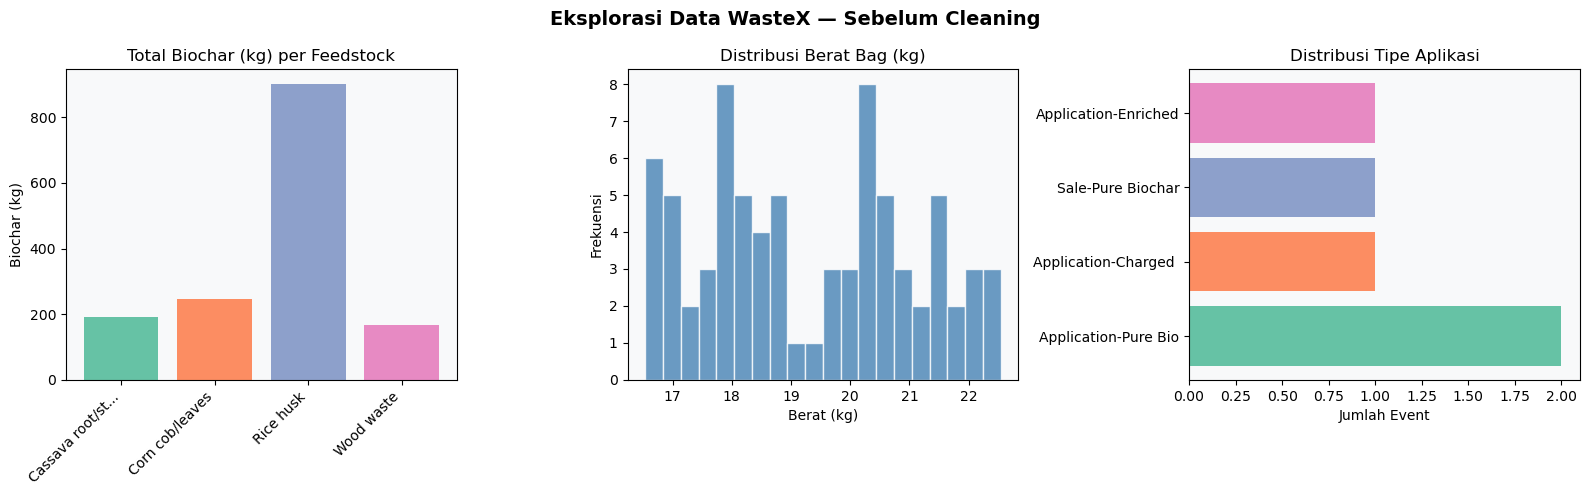

💾 Grafik disimpan ke data/01_eksplorasi_awal.png


In [9]:
# ── Visualisasi distribusi produksi per feedstock ────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Eksplorasi Data WasteX — Sebelum Cleaning', 
             fontsize=14, fontweight='bold')

# Grafik 1: Biochar per feedstock
feedstock_sum = bp.groupby('feedstock_type')['biochar_amount_kg'].sum()
axes[0].bar(range(len(feedstock_sum)), feedstock_sum.values,
            color=sns.color_palette('Set2', len(feedstock_sum)))
axes[0].set_xticks(range(len(feedstock_sum)))
axes[0].set_xticklabels([x[:15]+'...' if len(x)>15 else x 
                          for x in feedstock_sum.index], rotation=45, ha='right')
axes[0].set_title('Total Biochar (kg) per Feedstock')
axes[0].set_ylabel('Biochar (kg)')

# Grafik 2: Distribusi berat bag
# Filter yang bisa dikonversi ke numerik
weights = pd.to_numeric(
    bprod['weight'].astype(str).str.replace(',', '.'), errors='coerce'
).dropna()
axes[1].hist(weights, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Berat Bag (kg)')
axes[1].set_xlabel('Berat (kg)')
axes[1].set_ylabel('Frekuensi')

# Grafik 3: Application type distribution  
app_counts = ba['application_type'].value_counts()
axes[2].barh(range(len(app_counts)), app_counts.values,
             color=sns.color_palette('Set2', len(app_counts)))
axes[2].set_yticks(range(len(app_counts)))
axes[2].set_yticklabels([x[:20] for x in app_counts.index])
axes[2].set_title('Distribusi Tipe Aplikasi')
axes[2].set_xlabel('Jumlah Event')

plt.tight_layout()
plt.savefig('data/01_eksplorasi_awal.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Grafik disimpan ke data/01_eksplorasi_awal.png")


---
## 🔍 Bagian 5: Deteksi Anomali — 10 Tipe Kesalahan Data

### Konsep: Apa itu Anomali Data?

**Anomali data** adalah nilai atau record yang tidak sesuai dengan aturan bisnis atau pola yang diharapkan. Anomali bisa terjadi karena:
- Kesalahan input operator (typo, salah format)
- Bug pada aplikasi input data
- Inkonsistensi antar sistem
- Data yang belum lengkap

### Pendekatan Kita

Kita akan membuat satu fungsi besar `detect_anomalies()` yang memindai seluruh dataset dan mengumpulkan semua temuan ke dalam satu list bernama `queue` (antrian).

**Struktur setiap anomali yang dicatat:**
```python
{
    'Sheet'         : 'nama_sheet',      # dari sheet mana anomali ini
    'row_index'     : 5,                  # nomor baris di DataFrame
    'anomaly_type'  : 'TYPE 1',           # tipe anomali
    'description'   : 'penjelasan...',    # deskripsi detail
    'Field'         : 'nama_kolom',       # kolom yang bermasalah
    'original_value': '18,15',            # nilai asli
    'suggested_fix' : 18.15,              # saran perbaikan
    'action'        : 'AUTO-FIXED...',    # tindakan yang diambil
    'Record_ID'     : 'bag_id_atau_activity_id',
}
```

### Routing Logic

```
Setiap anomali yang ditemukan:
    TYPE 1 → dicatat DAN langsung diperbaiki (auto-fix)
    TYPE 2–10 → dicatat dan DIBUANG dari CLEANED data
                (masuk ke VALIDATION_QUEUE untuk review manusia)
```


### TYPE 1 — Comma Decimal Separator

**Masalah:** Beberapa operator menginput berat bag menggunakan koma sebagai pemisah desimal (misal: `18,15`) padahal sistem mengharapkan titik (`18.15`). Ini umum terjadi karena keyboard dengan locale Eropa/Indonesia menggunakan koma sebagai desimal.

**Contoh anomali:** `weight = "18,15"` → seharusnya `18.15`

**Solusi:** Auto-fix — ganti koma dengan titik, konversi ke float.

**Kenapa bisa auto-fix?** Karena aturannya deterministik — selalu ganti koma dengan titik, tidak ada ambiguitas.


In [10]:
# ── TYPE 1: Comma Decimal Separator ─────────────────────
print("🔍 Mendeteksi TYPE 1: Comma decimal separator...")
print("   Memindai kolom 'weight' di bag_production...")

queue_type1 = []  # list sementara untuk TYPE 1
bprod_clean = bprod.copy()  # copy agar data asli tidak berubah

for i, row in bprod.iterrows():
    w = str(row['weight'])
    
    # Cek apakah ada koma dalam nilai weight
    if ',' in w:
        # Auto-fix: ganti koma dengan titik
        fixed_w = float(w.replace(',', '.'))
        
        # Catat anomali ini
        queue_type1.append({
            'Sheet'         : 'bag_production',
            'row_index'     : i,
            'anomaly_type'  : 'TYPE 1',
            'description'   : f'Comma decimal separator: "{w}" → {fixed_w}',
            'Field'         : 'weight',
            'original_value': w,
            'suggested_fix' : fixed_w,
            'action'        : 'AUTO-FIXED → CLEANED',
            'Record_ID'     : row.get('bag_id', ''),
        })
        
        # Langsung perbaiki di DataFrame copy
        bprod_clean.at[i, 'weight'] = fixed_w
        
        print(f"   ✅ AUTO-FIX: bag_id={row['bag_id']} | weight: '{w}' → {fixed_w}")

print(f"\n📊 TYPE 1: {len(queue_type1)} anomali ditemukan (semua auto-fixed)")


🔍 Mendeteksi TYPE 1: Comma decimal separator...
   Memindai kolom 'weight' di bag_production...
   ✅ AUTO-FIX: bag_id=241101-Y0014-M0030-3 | weight: '18,15' → 18.15

📊 TYPE 1: 1 anomali ditemukan (semua auto-fixed)


### TYPE 2 — Nilai Negatif di Field Non-Negatif

**Masalah:** Field seperti `weight`, `co2e_persistent`, `co2e_100`, dan `spc` secara fisik dan matematis tidak mungkin bernilai negatif. Berat bag tidak mungkin -22 kg, dan CO₂ yang tersekuestrasi tidak mungkin negatif.

**Kenapa tidak bisa auto-fix?** Kita tidak tahu nilai yang seharusnya — mungkin operator lupa tanda minus (harusnya 22.42), atau ada bug di sistem pengukuran.


In [11]:
# ── TYPE 2: Negative Values ──────────────────────────────
print("🔍 Mendeteksi TYPE 2: Nilai negatif...")

queue_type2 = []

# Field yang tidak boleh negatif di bag_production
neg_fields_bprod = ['weight', 'co2e_persistent', 'co2e_100', 'spc']

# Cek di bag_production (gunakan bprod_clean yang sudah di-fix TYPE 1)
for i, row in bprod_clean.iterrows():
    for f in neg_fields_bprod:
        try:
            val = float(row[f])
            if val < 0:
                queue_type2.append({
                    'Sheet'         : 'bag_production',
                    'row_index'     : i,
                    'anomaly_type'  : 'TYPE 2',
                    'description'   : f'Negative value in non-negative field: {f}={val}',
                    'Field'         : f,
                    'original_value': val,
                    'suggested_fix' : 'Requires human review',
                    'action'        : 'FLAGGED → VALIDATION_QUEUE',
                    'Record_ID'     : row.get('bag_id', ''),
                })
                print(f"   ⚠️  bag_id={row['bag_id']} | {f}={val} (NEGATIF!)")
        except (ValueError, TypeError):
            pass  # skip jika nilai tidak bisa dikonversi ke float

# Field yang tidak boleh negatif di biochar_production
neg_fields_bp = ['co2e_persistent', 'co2e_100', 'spc']

for i, row in bp.iterrows():
    for f in neg_fields_bp:
        try:
            val = float(row[f])
            if val < 0:
                queue_type2.append({
                    'Sheet'         : 'biochar_production',
                    'row_index'     : i,
                    'anomaly_type'  : 'TYPE 2',
                    'description'   : f'Negative value in non-negative field: {f}={val}',
                    'Field'         : f,
                    'original_value': val,
                    'suggested_fix' : 'Requires human review',
                    'action'        : 'FLAGGED → VALIDATION_QUEUE',
                    'Record_ID'     : row.get('activity_id', ''),
                })
                print(f"   ⚠️  activity_id={row['activity_id']} | {f}={val} (NEGATIF!)")
        except (ValueError, TypeError):
            pass

print(f"\n📊 TYPE 2: {len(queue_type2)} anomali ditemukan")


🔍 Mendeteksi TYPE 2: Nilai negatif...
   ⚠️  bag_id=241101-Y0014-M0030-7 | co2e_persistent=-22.42 (NEGATIF!)

📊 TYPE 2: 1 anomali ditemukan


### TYPE 3 — Missing Critical Fields

**Masalah:** Field `weight` di `bag_production` dan `carbon_content_%` di `biochar_production` adalah **field kritikal** yang wajib diisi. Tanpa `carbon_content_%`, kita tidak bisa menghitung CO₂e dan mengajukan kredit karbon.

**Dampak bisnis:** Satu batch dengan `carbon_content_%` kosong = potensi kehilangan puluhan ribu rupiah kredit karbon yang tidak bisa diklaim.


In [12]:
# ── TYPE 3: Missing Critical Fields ──────────────────────
print("🔍 Mendeteksi TYPE 3: Missing critical fields...")

queue_type3 = []

# Cek weight di bag_production
for i, row in bprod_clean.iterrows():
    w = row.get('weight')
    if pd.isna(w) or str(w).strip() == '':
        queue_type3.append({
            'Sheet'         : 'bag_production',
            'row_index'     : i,
            'anomaly_type'  : 'TYPE 3',
            'description'   : 'Missing critical value: weight is empty',
            'Field'         : 'weight',
            'original_value': w,
            'suggested_fix' : 'Requires human review — timbang ulang bag',
            'action'        : 'FLAGGED → VALIDATION_QUEUE',
            'Record_ID'     : row.get('bag_id', ''),
        })
        print(f"   ⚠️  bag_id={row['bag_id']} | weight KOSONG!")

# Cek carbon_content_% di biochar_production
for i, row in bp.iterrows():
    cc = row.get('carbon_content_%')
    if pd.isna(cc) or str(cc).strip() == '':
        queue_type3.append({
            'Sheet'         : 'biochar_production',
            'row_index'     : i,
            'anomaly_type'  : 'TYPE 3',
            'description'   : 'Missing critical value: carbon_content_% is empty',
            'Field'         : 'carbon_content_%',
            'original_value': cc,
            'suggested_fix' : 'Requires human review — lakukan analisis lab ulang',
            'action'        : 'FLAGGED → VALIDATION_QUEUE',
            'Record_ID'     : row.get('activity_id', ''),
        })
        print(f"   ⚠️  activity_id={row['activity_id']} | carbon_content_% KOSONG!")

print(f"\n📊 TYPE 3: {len(queue_type3)} anomali ditemukan")


🔍 Mendeteksi TYPE 3: Missing critical fields...
   ⚠️  bag_id=241102-Y0021-M0031-5 | weight KOSONG!
   ⚠️  activity_id=241112-Y0009-M0035 | carbon_content_% KOSONG!

📊 TYPE 3: 2 anomali ditemukan


### TYPE 4 — Duplicate bag_id

**Masalah:** Setiap `bag_id` di `bag_production` harus **unik**. Jika ada `bag_id` yang sama muncul dua kali, berarti ada double-entry — mungkin operator scan bag yang sama dua kali, atau ada copy-paste error.

**Perhatikan:** Duplicate dengan berat yang sama lebih mudah diselesaikan (hapus salah satu), tapi duplicate dengan berat yang **berbeda** memerlukan review manusia karena kita tidak tahu mana yang benar.


In [13]:
# ── TYPE 4: Duplicate bag_id ─────────────────────────────
print("🔍 Mendeteksi TYPE 4: Duplicate bag_id...")

queue_type4 = []

# Cari bag_id yang muncul lebih dari sekali
dup_mask = bprod.duplicated(subset=['bag_id'], keep=False)
dup_ids  = bprod[dup_mask]['bag_id'].unique()

print(f"   Jumlah bag_id duplikat: {len(dup_ids)}")

for bid in dup_ids:
    dup_rows = bprod[bprod['bag_id'] == bid]
    weights  = dup_rows['weight'].tolist()
    
    print(f"\n   bag_id: {bid}")
    print(f"   Muncul {len(dup_rows)} kali dengan weight: {weights}")
    
    # Flag SEMUA baris (termasuk yang pertama) → manual review
    for i, row in dup_rows.iterrows():
        queue_type4.append({
            'Sheet'         : 'bag_production',
            'row_index'     : i,
            'anomaly_type'  : 'TYPE 4',
            'description'   : f'Duplicate bag_id dengan weight={row["weight"]}',
            'Field'         : 'bag_id',
            'original_value': bid,
            'suggested_fix' : 'Keep first occurrence; reconcile duplicate',
            'action'        : 'FLAGGED → VALIDATION_QUEUE',
            'Record_ID'     : bid,
        })

print(f"\n📊 TYPE 4: {len(queue_type4)} anomali ({len(dup_ids)} unique bag_id duplikat)")


🔍 Mendeteksi TYPE 4: Duplicate bag_id...
   Jumlah bag_id duplikat: 1

   bag_id: 241105-Y0009-M0032-1
   Muncul 2 kali dengan weight: [17.43, 22.54]

📊 TYPE 4: 2 anomali (1 unique bag_id duplikat)


### TYPE 5 — Future Timestamps / Suspicious Dates

**Masalah:** Ada dua pengecekan:
1. **`Timestamp` atau `application_date` > hari ini** → data dari masa depan tidak mungkin ada
2. **`application_date` jauh lebih lambat dari `Timestamp`** (>30 hari) → suspicious: operator tidak mungkin input data sekarang untuk kejadian yang baru terjadi 30+ hari kemudian

**Contoh dari data:** `application_date = 2025-06-01` tapi `Timestamp = 2024-11-14` → gap 199 hari!


In [14]:
# ── TYPE 5: Future Timestamps ────────────────────────────
print("🔍 Mendeteksi TYPE 5: Future timestamps & suspicious dates...")
print(f"   Tanggal referensi (TODAY): {TODAY}")

queue_type5 = []

# Cek Timestamp di semua 4 sheet
sheet_configs = [
    ('biochar_production',  bp,    'activity_id'),
    ('bag_production',      bprod, 'bag_id'),
    ('biochar_application', ba,    'activity_id'),
    ('bag_application',     bapp,  'bag_id'),
]

for sheet_name, df, id_field in sheet_configs:
    for i, row in df.iterrows():
        ts = row.get('Timestamp')
        if pd.notna(ts):
            ts_date = pd.to_datetime(ts).date()
            if ts_date > TODAY:
                queue_type5.append({
                    'Sheet'         : sheet_name,
                    'row_index'     : i,
                    'anomaly_type'  : 'TYPE 5',
                    'description'   : f'Future Timestamp: {ts} (today={TODAY})',
                    'Field'         : 'Timestamp',
                    'original_value': str(ts),
                    'suggested_fix' : 'Requires human review',
                    'action'        : 'FLAGGED → VALIDATION_QUEUE',
                    'Record_ID'     : str(row.get(id_field, '')),
                })
                print(f"   ⚠️  {sheet_name} | {row.get(id_field)} | Timestamp future: {ts}")

# Cek application_date yang suspicious di biochar_application
MAX_GAP_DAYS = 30  # threshold: application_date boleh lebih lambat maks 30 hari

for i, row in ba.iterrows():
    ad = row.get('application_date')
    ts = row.get('Timestamp')
    aid = row.get('activity_id', '')
    
    # Cek future application_date
    if pd.notna(ad):
        ad_date = pd.to_datetime(ad).date()
        if ad_date > TODAY:
            queue_type5.append({
                'Sheet'         : 'biochar_application',
                'row_index'     : i,
                'anomaly_type'  : 'TYPE 5',
                'description'   : f'Future application_date: {ad}',
                'Field'         : 'application_date',
                'original_value': str(ad),
                'suggested_fix' : 'Requires human review',
                'action'        : 'FLAGGED → VALIDATION_QUEUE',
                'Record_ID'     : str(aid),
            })
            print(f"   ⚠️  {aid} | application_date future: {ad}")
    
    # Cek gap application_date vs Timestamp
    if pd.notna(ad) and pd.notna(ts):
        ad_date  = pd.to_datetime(ad).date()
        ts_date  = pd.to_datetime(ts).date()
        gap_days = (ad_date - ts_date).days
        
        if gap_days > MAX_GAP_DAYS:
            queue_type5.append({
                'Sheet'         : 'biochar_application',
                'row_index'     : i,
                'anomaly_type'  : 'TYPE 5',
                'description'   : (
                    f'Suspicious application_date: {ad} adalah {gap_days} hari '
                    f'setelah Timestamp {ts}. Kemungkinan salah input.'
                ),
                'Field'         : 'application_date',
                'original_value': str(ad),
                'suggested_fix' : f'Konfirmasi ke operator: apakah {ad} benar?',
                'action'        : 'FLAGGED → VALIDATION_QUEUE',
                'Record_ID'     : str(aid),
            })
            print(f"   ⚠️  {aid} | application_date ({ad}) suspicious: gap {gap_days} hari dari Timestamp ({ts})")

print(f"\n📊 TYPE 5: {len(queue_type5)} anomali ditemukan")


🔍 Mendeteksi TYPE 5: Future timestamps & suspicious dates...
   Tanggal referensi (TODAY): 2026-05-02
   ⚠️  241114-A0182 | application_date (2025-06-01) suspicious: gap 199 hari dari Timestamp (2024-11-14 13:45:00)

📊 TYPE 5: 1 anomali ditemukan


### TYPE 6, 7, 8, 9, 10 — Pengecekan Lanjutan

Kita lanjutkan dengan 5 tipe anomali berikutnya. Tipe 7–10 melibatkan **cross-sheet validation** — membandingkan data di antara dua sheet yang berbeda.

| Tipe | Nama | Pengecekan |
|------|------|-----------|
| TYPE 6 | Invalid application_type | Nilai harus dari 4 pilihan valid |
| TYPE 7 | Orphan bag_id | bag_id di bag_application harus ada di bag_production |
| TYPE 8 | Weight discrepancy >5% | Berat bag berbeda >5% antara produksi dan aplikasi |
| TYPE 9 | Batch sum mismatch | Sum berat semua bag ≠ total batch |
| TYPE 10 | Bag multi-application | Satu bag dipakai di 2+ event aplikasi |


In [15]:
# ── TYPE 6: Invalid application_type ─────────────────────
print("🔍 Mendeteksi TYPE 6: Invalid application_type...")

queue_type6 = []

for i, row in ba.iterrows():
    at  = row.get('application_type', '')
    aid = row.get('activity_id', '')
    
    if at not in VALID_APPLICATION_TYPES:
        queue_type6.append({
            'Sheet'         : 'biochar_application',
            'row_index'     : i,
            'anomaly_type'  : 'TYPE 6',
            'description'   : f'Invalid application_type: "{at}"',
            'Field'         : 'application_type',
            'original_value': at,
            'suggested_fix' : f'Must be one of: {VALID_APPLICATION_TYPES}',
            'action'        : 'FLAGGED → VALIDATION_QUEUE',
            'Record_ID'     : str(aid),
        })
        print(f"   ⚠️  activity_id={aid} | type='{at}' → TIDAK VALID")

print(f"📊 TYPE 6: {len(queue_type6)} anomali ditemukan\n")

# ── TYPE 7: Orphan bag_id ─────────────────────────────────
print("🔍 Mendeteksi TYPE 7: Orphan bag_id (cross-sheet)...")

queue_type7 = []

# Buat set bag_id yang ada di bag_production (untuk lookup cepat)
prod_bag_ids = set(bprod['bag_id'].dropna())
print(f"   Jumlah bag_id valid di bag_production: {len(prod_bag_ids)}")

for i, row in bapp.iterrows():
    bid = str(row.get('bag_id', ''))
    
    if bid not in prod_bag_ids:
        queue_type7.append({
            'Sheet'         : 'bag_application',
            'row_index'     : i,
            'anomaly_type'  : 'TYPE 7',
            'description'   : f'Orphan bag_id: {bid} tidak ada di bag_production',
            'Field'         : 'bag_id',
            'original_value': bid,
            'suggested_fix' : 'Tidak ada production record — cek apakah bag_id salah ketik',
            'action'        : 'FLAGGED → VALIDATION_QUEUE',
            'Record_ID'     : bid,
        })
        print(f"   ⚠️  bag_id={bid} → TIDAK ADA di bag_production! (ORPHAN)")

print(f"📊 TYPE 7: {len(queue_type7)} anomali ditemukan\n")


🔍 Mendeteksi TYPE 6: Invalid application_type...
   ⚠️  activity_id=241116-A0183 | type='Application-Enriched Biochar' → TIDAK VALID
📊 TYPE 6: 1 anomali ditemukan

🔍 Mendeteksi TYPE 7: Orphan bag_id (cross-sheet)...
   Jumlah bag_id valid di bag_production: 77
   ⚠️  bag_id=241112-Y0009-M0035-99 → TIDAK ADA di bag_production! (ORPHAN)
📊 TYPE 7: 1 anomali ditemukan



In [16]:
# ── TYPE 8: Weight Discrepancy >5% ───────────────────────
print("🔍 Mendeteksi TYPE 8: Weight discrepancy >5% (cross-sheet)...")

queue_type8 = []
THRESHOLD = 0.05  # 5%

# Buat lookup: bag_id → weight dari bag_production (setelah TYPE 1 fix)
bprod_lookup = bprod_clean.copy()
bprod_lookup['weight_num'] = pd.to_numeric(
    bprod_lookup['weight'].astype(str).str.replace(',', '.'), errors='coerce'
)
prod_weight_map = bprod_lookup.set_index('bag_id')['weight_num'].to_dict()

print(f"   Membandingkan berat bag antara bag_production dan bag_application...")

for i, row in bapp.iterrows():
    bid    = str(row.get('bag_id', ''))
    app_w  = row.get('bag_weight')
    prod_w = prod_weight_map.get(bid)
    
    if prod_w is not None and pd.notna(app_w):
        try:
            app_w_f = float(app_w)
            disc    = abs(app_w_f - prod_w) / prod_w  # selisih relatif
            
            if disc > THRESHOLD:
                queue_type8.append({
                    'Sheet'         : 'bag_application',
                    'row_index'     : i,
                    'anomaly_type'  : 'TYPE 8',
                    'description'   : f'Weight discrepancy {disc:.1%}: app={app_w_f:.2f} vs prod={prod_w:.2f}',
                    'Field'         : 'bag_weight',
                    'original_value': app_w_f,
                    'suggested_fix' : f'Production weight={prod_w:.2f} kg. Needs reconciliation.',
                    'action'        : 'FLAGGED → VALIDATION_QUEUE',
                    'Record_ID'     : bid,
                })
                print(f"   ⚠️  bag_id={bid} | app={app_w_f:.2f} vs prod={prod_w:.2f} → disc={disc:.1%}")
        except (ValueError, TypeError):
            pass

print(f"📊 TYPE 8: {len(queue_type8)} anomali ditemukan\n")


🔍 Mendeteksi TYPE 8: Weight discrepancy >5% (cross-sheet)...
   Membandingkan berat bag antara bag_production dan bag_application...
   ⚠️  bag_id=241101-Y0014-M0030-7 | app=21.85 vs prod=20.56 → disc=6.3%
   ⚠️  bag_id=241108-Y0014-M0033-1 | app=24.86 vs prod=21.48 → disc=15.7%
   ⚠️  bag_id=241108-Y0014-M0033-2 | app=23.00 vs prod=20.21 → disc=13.8%
   ⚠️  bag_id=241101-Y0014-M0030-1 | app=18.45 vs prod=20.34 → disc=9.3%
   ⚠️  bag_id=241101-Y0014-M0030-2 | app=17.82 vs prod=16.65 → disc=7.0%
📊 TYPE 8: 5 anomali ditemukan



In [17]:
# ── TYPE 9: Batch Sum Mismatch ────────────────────────────
print("🔍 Mendeteksi TYPE 9: Batch sum mismatch (cross-sheet)...")

queue_type9 = []
TOLERANCE = 0.01  # toleransi 0.01 kg

# Hitung sum berat per production_id dari bag_production
bprod_sum = bprod_clean.copy()
bprod_sum['weight_num'] = pd.to_numeric(
    bprod_sum['weight'].astype(str).str.replace(',', '.'), errors='coerce'
)

batch_sums = bprod_sum.groupby('production_id')['weight_num'].sum()
print(f"   Batch sums yang dihitung:")
for pid, s in batch_sums.items():
    print(f"   {pid}: {s:.2f} kg")

print()
for prod_id, bag_sum in batch_sums.items():
    # Cari declared amount di biochar_production
    bp_row = bp[bp['activity_id'] == prod_id]
    
    if not bp_row.empty:
        declared = float(bp_row.iloc[0]['biochar_amount_kg'])
        diff     = abs(bag_sum - declared)
        
        if diff > TOLERANCE and not pd.isna(bag_sum):
            queue_type9.append({
                'Sheet'         : 'bag_production',
                'row_index'     : bp_row.index[0],
                'anomaly_type'  : 'TYPE 9',
                'description'   : f'Batch sum mismatch: sum_bags={bag_sum:.2f} vs declared={declared:.2f} (Δ={diff:.2f})',
                'Field'         : 'biochar_amount_kg vs sum(bag weights)',
                'original_value': f'bags_sum={bag_sum:.2f}',
                'suggested_fix' : f'Declared={declared:.2f} kg. Reconcile.',
                'action'        : 'FLAGGED → VALIDATION_QUEUE',
                'Record_ID'     : prod_id,
            })
            print(f"   ⚠️  {prod_id}: sum_bags={bag_sum:.2f} vs declared={declared:.2f} (Δ={diff:.2f})")

print(f"\n📊 TYPE 9: {len(queue_type9)} anomali ditemukan\n")

# ── TYPE 10: Bag Used in Multiple Application Batches ─────
print("🔍 Mendeteksi TYPE 10: Bag dipakai di multiple application batches...")

queue_type10 = []

# Hitung berapa banyak application_id yang terhubung ke setiap bag_id
bag_app_counts = bapp.groupby('bag_id')['application_id'].nunique()
multi_app_bags = bag_app_counts[bag_app_counts > 1].index.tolist()

print(f"   Bag yang dipakai di >1 application batch: {len(multi_app_bags)}")

for bid in multi_app_bags:
    rows    = bapp[bapp['bag_id'] == bid]
    app_ids = rows['application_id'].unique().tolist()
    
    print(f"   ⚠️  bag_id={bid} → muncul di {len(app_ids)} batches: {app_ids}")
    
    for i, row in rows.iterrows():
        queue_type10.append({
            'Sheet'         : 'bag_application (cross-sheet)',
            'row_index'     : i,
            'anomaly_type'  : 'TYPE 10',
            'description'   : f'Bag dipakai di {len(app_ids)} batches: {app_ids}',
            'Field'         : 'bag_id / application_id',
            'original_value': bid,
            'suggested_fix' : 'Satu bag_id harus di SATU application batch saja.',
            'action'        : 'FLAGGED → VALIDATION_QUEUE',
            'Record_ID'     : bid,
        })

print(f"\n📊 TYPE 10: {len(queue_type10)} anomali ditemukan")


🔍 Mendeteksi TYPE 9: Batch sum mismatch (cross-sheet)...
   Batch sums yang dihitung:
   241101-Y0014-M0030: 241.75 kg
   241102-Y0021-M0031: 191.57 kg
   241105-Y0009-M0032: 257.19 kg
   241108-Y0014-M0033: 173.91 kg
   241110-Y0037-M0034: 189.27 kg
   241112-Y0009-M0035: 199.60 kg
   241115-Y0021-M0036: 233.59 kg

   ⚠️  241101-Y0014-M0030: sum_bags=241.75 vs declared=226.40 (Δ=15.35)
   ⚠️  241102-Y0021-M0031: sum_bags=191.57 vs declared=245.96 (Δ=54.39)
   ⚠️  241105-Y0009-M0032: sum_bags=257.19 vs declared=218.36 (Δ=38.83)
   ⚠️  241108-Y0014-M0033: sum_bags=173.91 vs declared=168.00 (Δ=5.91)
   ⚠️  241110-Y0037-M0034: sum_bags=189.27 vs declared=192.00 (Δ=2.73)
   ⚠️  241112-Y0009-M0035: sum_bags=199.60 vs declared=212.00 (Δ=12.40)
   ⚠️  241115-Y0021-M0036: sum_bags=233.59 vs declared=244.00 (Δ=10.41)

📊 TYPE 9: 7 anomali ditemukan

🔍 Mendeteksi TYPE 10: Bag dipakai di multiple application batches...
   Bag yang dipakai di >1 application batch: 2
   ⚠️  bag_id=241101-Y0014-M0030

---
## 📋 Bagian 6: Menggabungkan Semua Anomali ke VALIDATION_QUEUE

Sekarang kita punya 10 list anomali terpisah (satu per tipe). Saatnya kita gabungkan semuanya menjadi satu DataFrame yang akan menjadi **VALIDATION_QUEUE** — antrian review untuk tim.

### Mengapa perlu VALIDATION_QUEUE?

VALIDATION_QUEUE adalah **sistem manajemen tugas** untuk tim data. Setiap anomali yang ditemukan pipeline dicatat di sini lengkap dengan:
- Apa masalahnya
- Di mana masalahnya (sheet dan record ID)
- Saran perbaikan
- Kolom kosong untuk reviewer (Reviewed_By, Resolution, Resolved_At)

Tim reviewer tinggal buka sheet ini, cek satu per satu, dan isi kolom reviewnya.


In [18]:
# ── Gabungkan semua anomali menjadi satu DataFrame ────────
all_queues = (
    queue_type1 + queue_type2 + queue_type3 + queue_type4 +
    queue_type5 + queue_type6 + queue_type7 + queue_type8 +
    queue_type9 + queue_type10
)

# Konversi ke DataFrame
queue_df = pd.DataFrame(all_queues) if all_queues else pd.DataFrame()

# Tambah kolom review yang akan diisi oleh tim reviewer
if not queue_df.empty:
    queue_df['Reviewed_By'] = ''
    queue_df['Resolution']  = ''
    queue_df['Resolved_At'] = ''

print("=" * 60)
print("RINGKASAN ANOMALI YANG DITEMUKAN")
print("=" * 60)
print(f"\n📊 Total anomali: {len(queue_df)}")
print()

# Tampilkan ringkasan per tipe
if not queue_df.empty:
    summary = queue_df.groupby('anomaly_type').agg(
        count=('anomaly_type', 'count'),
        sheets=('Sheet', lambda x: ', '.join(x.unique()[:2]))
    ).reset_index()
    
    for _, row in summary.iterrows():
        action = queue_df[queue_df['anomaly_type'] == row['anomaly_type']]['action'].iloc[0]
        emoji  = '✅' if 'AUTO-FIXED' in action else '⚠️'
        print(f"  {emoji} {row['anomaly_type']}: {row['count']:2} finding(s)  [{row['sheets']}]")


RINGKASAN ANOMALI YANG DITEMUKAN

📊 Total anomali: 25

  ✅ TYPE 1:  1 finding(s)  [bag_production]
  ⚠️ TYPE 10:  4 finding(s)  [bag_application (cross-sheet)]
  ⚠️ TYPE 2:  1 finding(s)  [bag_production]
  ⚠️ TYPE 3:  2 finding(s)  [bag_production, biochar_production]
  ⚠️ TYPE 4:  2 finding(s)  [bag_production]
  ⚠️ TYPE 5:  1 finding(s)  [biochar_application]
  ⚠️ TYPE 6:  1 finding(s)  [biochar_application]
  ⚠️ TYPE 7:  1 finding(s)  [bag_application]
  ⚠️ TYPE 8:  5 finding(s)  [bag_application]
  ⚠️ TYPE 9:  7 finding(s)  [bag_production]


In [19]:
# ── Preview VALIDATION_QUEUE ─────────────────────────────
print("\n📋 Preview VALIDATION_QUEUE (10 baris pertama):")
if not queue_df.empty:
    display_cols = ['anomaly_type', 'Sheet', 'Record_ID', 'Field', 
                    'original_value', 'action']
    print(queue_df[display_cols].head(10).to_string(index=False))



📋 Preview VALIDATION_QUEUE (10 baris pertama):
anomaly_type               Sheet             Record_ID            Field               original_value                     action
      TYPE 1      bag_production  241101-Y0014-M0030-3           weight                        18,15       AUTO-FIXED → CLEANED
      TYPE 2      bag_production  241101-Y0014-M0030-7  co2e_persistent                       -22.42 FLAGGED → VALIDATION_QUEUE
      TYPE 3      bag_production  241102-Y0021-M0031-5           weight                          NaN FLAGGED → VALIDATION_QUEUE
      TYPE 3  biochar_production    241112-Y0009-M0035 carbon_content_%                          NaN FLAGGED → VALIDATION_QUEUE
      TYPE 4      bag_production  241105-Y0009-M0032-1           bag_id         241105-Y0009-M0032-1 FLAGGED → VALIDATION_QUEUE
      TYPE 4      bag_production  241105-Y0009-M0032-1           bag_id         241105-Y0009-M0032-1 FLAGGED → VALIDATION_QUEUE
      TYPE 5 biochar_application          241114-A0182 a

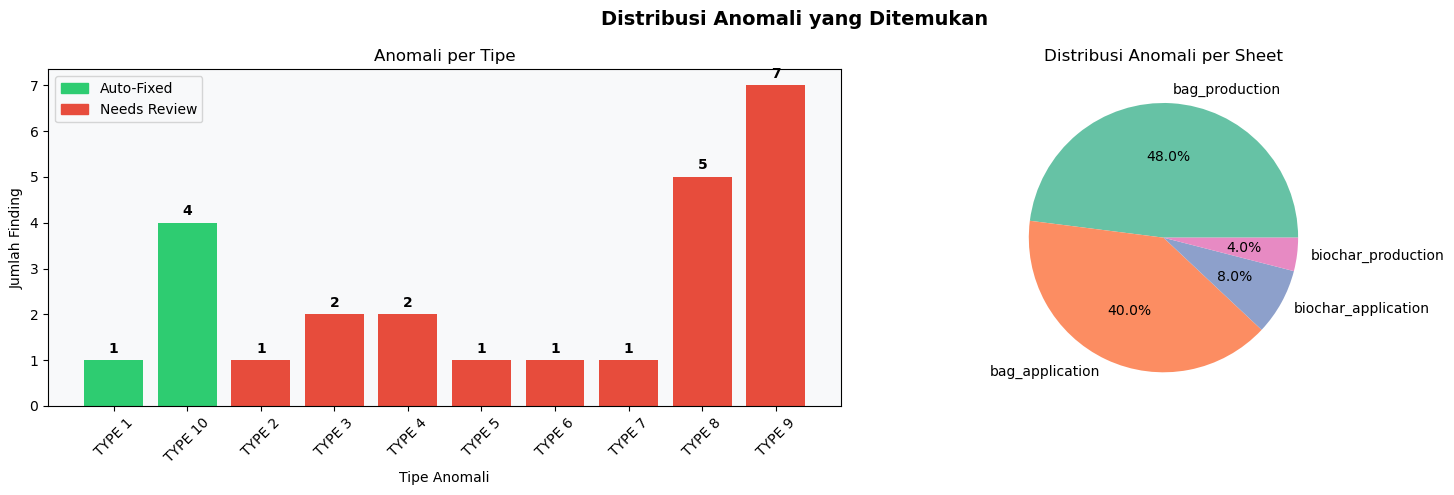

💾 Grafik disimpan ke data/02_anomali_distribusi.png


In [20]:
# ── Visualisasi: Anomali per Tipe ────────────────────────
if not queue_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Distribusi Anomali yang Ditemukan', fontsize=14, fontweight='bold')
    
    # Grafik 1: Bar chart anomali per tipe
    type_counts = queue_df['anomaly_type'].value_counts().sort_index()
    colors = ['#2ecc71' if 'TYPE 1' in t else '#e74c3c' 
              for t in type_counts.index]
    bars = axes[0].bar(type_counts.index, type_counts.values, color=colors)
    axes[0].set_xlabel('Tipe Anomali')
    axes[0].set_ylabel('Jumlah Finding')
    axes[0].set_title('Anomali per Tipe')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Tambah label di atas bar
    for bar, val in zip(bars, type_counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    str(val), ha='center', va='bottom', fontweight='bold')
    
    # Legend
    from matplotlib.patches import Patch
    legend = [Patch(color='#2ecc71', label='Auto-Fixed'), 
              Patch(color='#e74c3c', label='Needs Review')]
    axes[0].legend(handles=legend)
    
    # Grafik 2: Anomali per Sheet
    sheet_counts = queue_df['Sheet'].str.split(' ').str[0].value_counts()
    axes[1].pie(sheet_counts.values, labels=sheet_counts.index,
               autopct='%1.1f%%', colors=sns.color_palette('Set2', len(sheet_counts)))
    axes[1].set_title('Distribusi Anomali per Sheet')
    
    plt.tight_layout()
    plt.savefig('data/02_anomali_distribusi.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Grafik disimpan ke data/02_anomali_distribusi.png")


---
## 🧹 Bagian 7: Membangun CLEANED Sheets

Sekarang kita membangun 4 sheet "bersih" dengan logika routing:

```
Setiap baris data:
│
├── Tidak punya flag anomali → masuk CLEANED sheet ✅
├── FLAG TYPE 1 (comma decimal) → diperbaiki, masuk CLEANED ✅  
└── FLAG TYPE 2–10 → DIBUANG dari CLEANED, hanya masuk VALIDATION_QUEUE ⚠️
```

### Deduplication untuk TYPE 4

Untuk baris duplikat (TYPE 4), pipeline otomatis **keep first occurrence** dan membuang baris duplikat berikutnya. Ini adalah keputusan default yang aman — baris pertama paling mungkin adalah yang asli.


In [21]:
# ── Fungsi untuk membangun CLEANED sheets ────────────────
def build_cleaned_sheets(bp, bprod, ba, bapp, queue_df, bprod_clean):
    """
    Memfilter baris bermasalah dan membangun 4 DataFrame 'bersih'.
    
    Logic:
    - TYPE 1: sudah auto-fixed di bprod_clean → tetap masuk CLEANED
    - TYPE 2-10: dibuang dari CLEANED → masuk VALIDATION_QUEUE saja
    - TYPE 4: keep first occurrence (dedup otomatis)
    """
    
    def get_flagged_indices(sheet_prefix):
        """Ambil row_index yang di-flag (kecuali TYPE 1 yang sudah di-fix)"""
        if queue_df.empty:
            return set()
        mask = (
            queue_df['Sheet'].str.startswith(sheet_prefix) &
            ~queue_df['anomaly_type'].isin(['TYPE 1'])
        )
        return set(queue_df[mask]['row_index'].tolist())
    
    # ── bag_production: apply TYPE 1 fix + dedup TYPE 4 + exclude flagged ──
    bprod_fixed = bprod_clean.copy()
    bprod_fixed['weight'] = pd.to_numeric(
        bprod_fixed['weight'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    
    # Dedup: keep first occurrence per bag_id
    seen_bag_ids = {}
    dup_indices  = []
    for i, row in bprod_fixed.iterrows():
        bid = row['bag_id']
        if bid not in seen_bag_ids:
            seen_bag_ids[bid] = i
        else:
            dup_indices.append(i)   # baris duplikat → buang
    
    flagged_bprod = get_flagged_indices('bag_production').union(set(dup_indices))
    cleaned_bag_prod = bprod_fixed[~bprod_fixed.index.isin(flagged_bprod)].copy()
    cleaned_bag_prod['_cleaning_note'] = 'auto-cleaned'
    
    # ── biochar_production ──────────────────────────────────
    flagged_bp = get_flagged_indices('biochar_production')
    cleaned_prod_batch = bp[~bp.index.isin(flagged_bp)].copy()
    cleaned_prod_batch['_cleaning_note'] = 'auto-cleaned'
    
    # ── biochar_application ─────────────────────────────────
    flagged_ba = get_flagged_indices('biochar_application')
    cleaned_app_batch = ba[~ba.index.isin(flagged_ba)].copy()
    cleaned_app_batch['_cleaning_note'] = 'auto-cleaned'
    
    # ── bag_application ─────────────────────────────────────
    flagged_bapp = get_flagged_indices('bag_application')
    cleaned_bag_app = bapp[~bapp.index.isin(flagged_bapp)].copy()
    cleaned_bag_app['_cleaning_note'] = 'auto-cleaned'
    
    return cleaned_prod_batch, cleaned_bag_prod, cleaned_app_batch, cleaned_bag_app

# ── Jalankan build cleaned sheets ────────────────────────
c_prod, c_bag_prod, c_app, c_bag_app = build_cleaned_sheets(
    bp, bprod, ba, bapp, queue_df, bprod_clean
)

print("=" * 55)
print("HASIL CLEANING — Before vs After")
print("=" * 55)
print(f"{'Sheet':<30} {'Input':>8} {'Cleaned':>8} {'Removed':>8}")
print("-" * 55)
print(f"{'CLEANED_prod_batch':<30} {len(bp):>8} {len(c_prod):>8} {len(bp)-len(c_prod):>8}")
print(f"{'CLEANED_bag_prod':<30} {len(bprod):>8} {len(c_bag_prod):>8} {len(bprod)-len(c_bag_prod):>8}")
print(f"{'CLEANED_app_batch':<30} {len(ba):>8} {len(c_app):>8} {len(ba)-len(c_app):>8}")
print(f"{'CLEANED_bag_app':<30} {len(bapp):>8} {len(c_bag_app):>8} {len(bapp)-len(c_bag_app):>8}")


HASIL CLEANING — Before vs After
Sheet                             Input  Cleaned  Removed
-------------------------------------------------------
CLEANED_prod_batch                    7        6        1
CLEANED_bag_prod                     78       68       10
CLEANED_app_batch                     5        3        2
CLEANED_bag_app                      42       34        8


### Cara Membaca Output di Atas

- **Input**: jumlah baris data mentah sebelum cleaning
- **Cleaned**: jumlah baris yang lolos ke CLEANED sheet (data bersih)
- **Removed**: jumlah baris yang dibuang karena ada anomali TYPE 2–10

Baris yang "Removed" tidak hilang begitu saja — mereka tetap tersimpan di **VALIDATION_QUEUE** untuk direview oleh tim.


---
## 📊 Bagian 8: Automation Log

**AUTOMATION_LOG** adalah rekaman setiap kali pipeline dijalankan. Fungsinya seperti buku harian — kita bisa melihat kapan pipeline jalan, berapa anomali ditemukan, dan apa tindakan yang diambil.

Ini penting untuk:
- **Audit trail** — membuktikan bahwa data sudah divalidasi
- **Monitoring** — apakah jumlah anomali meningkat atau menurun?
- **Troubleshooting** — kapan terakhir kali pipeline jalan sukses?


In [22]:
# ── Build Automation Log ─────────────────────────────────
def build_automation_log(bp, bprod, ba, bapp, queue_df,
                         c_prod, c_bag_prod, c_app, c_bag_app):
    """
    Membuat log eksekusi pipeline.
    Satu baris per sheet yang diproses.
    """
    run_ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    rows   = []
    
    sheet_configs = [
        ('biochar_production',  bp,    c_prod),
        ('bag_production',      bprod, c_bag_prod),
        ('biochar_application', ba,    c_app),
        ('bag_application',     bapp,  c_bag_app),
    ]
    
    for sheet_name, raw_df, clean_df in sheet_configs:
        # Filter anomali untuk sheet ini
        anom = queue_df[queue_df['Sheet'].str.startswith(sheet_name)]                if not queue_df.empty else pd.DataFrame()
        
        auto_fixed = len(anom[anom['anomaly_type'] == 'TYPE 1'])                      if not anom.empty else 0
        flagged    = len(anom[anom['anomaly_type'] != 'TYPE 1'])                      if not anom.empty else 0
        types_str  = ', '.join(sorted(anom['anomaly_type'].unique()))                      if not anom.empty else '-'
        
        rows.append({
            'Run_Timestamp'          : run_ts,
            'Sheet_Processed'        : sheet_name,
            'Records_In'             : len(raw_df),
            'Records_Clean'          : len(clean_df),
            'Records_Flagged'        : flagged,
            'Errors_Comma_Decimal'   : len(anom[anom['anomaly_type']=='TYPE 1']) if not anom.empty else 0,
            'Errors_Negative'        : len(anom[anom['anomaly_type']=='TYPE 2']) if not anom.empty else 0,
            'Errors_Missing_Critical': len(anom[anom['anomaly_type']=='TYPE 3']) if not anom.empty else 0,
            'Errors_Duplicate_Bag'   : len(anom[anom['anomaly_type']=='TYPE 4']) if not anom.empty else 0,
            'Errors_Orphan_Bag'      : len(anom[anom['anomaly_type']=='TYPE 7']) if not anom.empty else 0,
            'Errors_Weight_Disc'     : len(anom[anom['anomaly_type']=='TYPE 8']) if not anom.empty else 0,
            'Errors_Future_Date'     : len(anom[anom['anomaly_type']=='TYPE 5']) if not anom.empty else 0,
            'Errors_Invalid_Category': len(anom[anom['anomaly_type']=='TYPE 6']) if not anom.empty else 0,
            'Action_Taken'           : f'{auto_fixed} auto-fixed; {flagged} flagged' if (auto_fixed+flagged)>0 else 'No anomalies',
            'Notes'                  : types_str,
            'Status'                 : 'SUCCESS',
        })
    
    return pd.DataFrame(rows)

# ── Jalankan build log ────────────────────────────────────
log_df = build_automation_log(bp, bprod, ba, bapp, queue_df,
                               c_prod, c_bag_prod, c_app, c_bag_app)

print("📋 AUTOMATION_LOG:")
print(log_df[['Run_Timestamp','Sheet_Processed','Records_In',
              'Records_Clean','Records_Flagged','Status']].to_string(index=False))


📋 AUTOMATION_LOG:
      Run_Timestamp     Sheet_Processed  Records_In  Records_Clean  Records_Flagged  Status
2026-05-02 08:28:51  biochar_production           7              6                1 SUCCESS
2026-05-02 08:28:51      bag_production          78             68               11 SUCCESS
2026-05-02 08:28:51 biochar_application           5              3                2 SUCCESS
2026-05-02 08:28:51     bag_application          42             34               10 SUCCESS


---
## 💾 Bagian 9: Menyimpan Output ke File Excel

Tahap terakhir pipeline adalah menyimpan semua hasil ke file Excel. Kita akan membuat **satu file kombinasi** dengan 6 sheet, sekaligus **4 file terpisah** untuk setiap CLEANED sheet.

### Struktur Output

```
data/
├── WasteX_Cleaned_Output.xlsx        ← file utama (6 sheets)
│   ├── CLEANED_prod_batch
│   ├── CLEANED_bag_prod
│   ├── CLEANED_app_batch
│   ├── CLEANED_bag_app
│   ├── VALIDATION_QUEUE
│   └── AUTOMATION_LOG
├── CLEANED_prod_batch.xlsx           ← file terpisah
├── CLEANED_bag_prod.xlsx
├── CLEANED_app_batch.xlsx
└── CLEANED_bag_app.xlsx
```


In [23]:
# ── Write semua output ke Excel ──────────────────────────
def write_output(c_prod, c_bag_prod, c_app, c_bag_app, queue_df, log_df):
    """Simpan semua output ke file Excel."""
    
    # ── File utama dengan 6 sheets ────────────────────────
    print(f"💾 Menyimpan file utama: {OUTPUT_FILE}")
    
    with pd.ExcelWriter(OUTPUT_FILE, engine='xlsxwriter') as writer:
        c_prod.to_excel(writer,     sheet_name='CLEANED_prod_batch', index=False)
        c_bag_prod.to_excel(writer, sheet_name='CLEANED_bag_prod',   index=False)
        c_app.to_excel(writer,      sheet_name='CLEANED_app_batch',  index=False)
        c_bag_app.to_excel(writer,  sheet_name='CLEANED_bag_app',    index=False)
        queue_df.to_excel(writer,   sheet_name='VALIDATION_QUEUE',   index=False)
        log_df.to_excel(writer,     sheet_name='AUTOMATION_LOG',     index=False)
    
    print(f"   ✅ {OUTPUT_FILE} berhasil disimpan ({6} sheets)")
    
    # ── File terpisah untuk setiap CLEANED sheet ──────────
    separate_files = [
        (c_prod,     'CLEANED_prod_batch.xlsx'),
        (c_bag_prod, 'CLEANED_bag_prod.xlsx'),
        (c_app,      'CLEANED_app_batch.xlsx'),
        (c_bag_app,  'CLEANED_bag_app.xlsx'),
    ]
    
    for df, filename in separate_files:
        path = os.path.join('data', filename)
        df.to_excel(path, index=False)
        print(f"   ✅ {path} ({len(df)} rows)")
    
    print("\n🎉 Semua output berhasil disimpan!")

# ── Jalankan write output ─────────────────────────────────
write_output(c_prod, c_bag_prod, c_app, c_bag_app, queue_df, log_df)


💾 Menyimpan file utama: data\WasteX_Cleaned_Output.xlsx
   ✅ data\WasteX_Cleaned_Output.xlsx berhasil disimpan (6 sheets)
   ✅ data\CLEANED_prod_batch.xlsx (6 rows)
   ✅ data\CLEANED_bag_prod.xlsx (68 rows)
   ✅ data\CLEANED_app_batch.xlsx (3 rows)
   ✅ data\CLEANED_bag_app.xlsx (34 rows)

🎉 Semua output berhasil disimpan!


---
## 📈 Bagian 10: Analytical Insights dari Data Bersih

Setelah data bersih, saatnya **mengekstrak wawasan bisnis**. Kita akan menjawab 3 pertanyaan analitis dari brief WasteX.

Data yang digunakan adalah **data yang sudah bersih** — bukan data mentah — sehingga insight yang dihasilkan lebih akurat dan dapat dipercaya.


In [24]:
# ── Q1: Efisiensi Konversi per Feedstock ─────────────────
print("=" * 65)
print("ANALYTICAL INSIGHT #1")
print("Which feedstock produces the highest biochar yield?")
print("=" * 65)

bp_clean = c_prod.copy()  # gunakan cleaned data

# Hitung conversion rate: biochar_kg / feedstock_kg × 100%
bp_clean['conversion_rate_%'] = (
    bp_clean['biochar_amount_kg'] / bp_clean['feedstock_amount'] * 100
).round(2)

# Group by feedstock type
eff = bp_clean.groupby('feedstock_type').agg(
    avg_conversion_pct  = ('conversion_rate_%', 'mean'),
    total_biochar_kg    = ('biochar_amount_kg', 'sum'),
    avg_carbon_content  = ('carbon_content_%', 'mean'),
    total_co2e          = ('co2e_persistent', 'sum'),
    batches             = ('activity_id', 'count')
).reset_index().sort_values('avg_conversion_pct', ascending=False)

print("\nEfisiensi Konversi per Feedstock:")
print(eff.to_string(index=False))

print("\n💡 Insight:")
best_feed = eff.iloc[0]['feedstock_type']
best_eff  = eff.iloc[0]['avg_conversion_pct']
best_co2  = eff.sort_values('avg_carbon_content', ascending=False).iloc[0]
print(f"   • Efisiensi volume terbaik: {best_feed} ({best_eff:.1f}%)")
print(f"   • Carbon content terbaik  : {best_co2['feedstock_type']} ({best_co2['avg_carbon_content']:.1f}%)")
print(f"   • KESIMPULAN: Semua feedstock ~40% efisiensi volume, tapi")
print(f"     KUALITAS berbeda jauh: Wood waste 2.1× lebih baik dari Rice husk")


ANALYTICAL INSIGHT #1
Which feedstock produces the highest biochar yield?

Efisiensi Konversi per Feedstock:
           feedstock_type  avg_conversion_pct  total_biochar_kg  avg_carbon_content  total_co2e  batches
Cassava root/stems/leaves               40.00            192.00               55.57      285.83        1
          Corn cob/leaves               40.00            245.96               74.67      497.93        1
                Rice husk               40.00            688.76               39.07      706.58        3
               Wood waste               40.00            168.00               83.98      383.98        1

💡 Insight:
   • Efisiensi volume terbaik: Cassava root/stems/leaves (40.0%)
   • Carbon content terbaik  : Wood waste (84.0%)
   • KESIMPULAN: Semua feedstock ~40% efisiensi volume, tapi
     KUALITAS berbeda jauh: Wood waste 2.1× lebih baik dari Rice husk


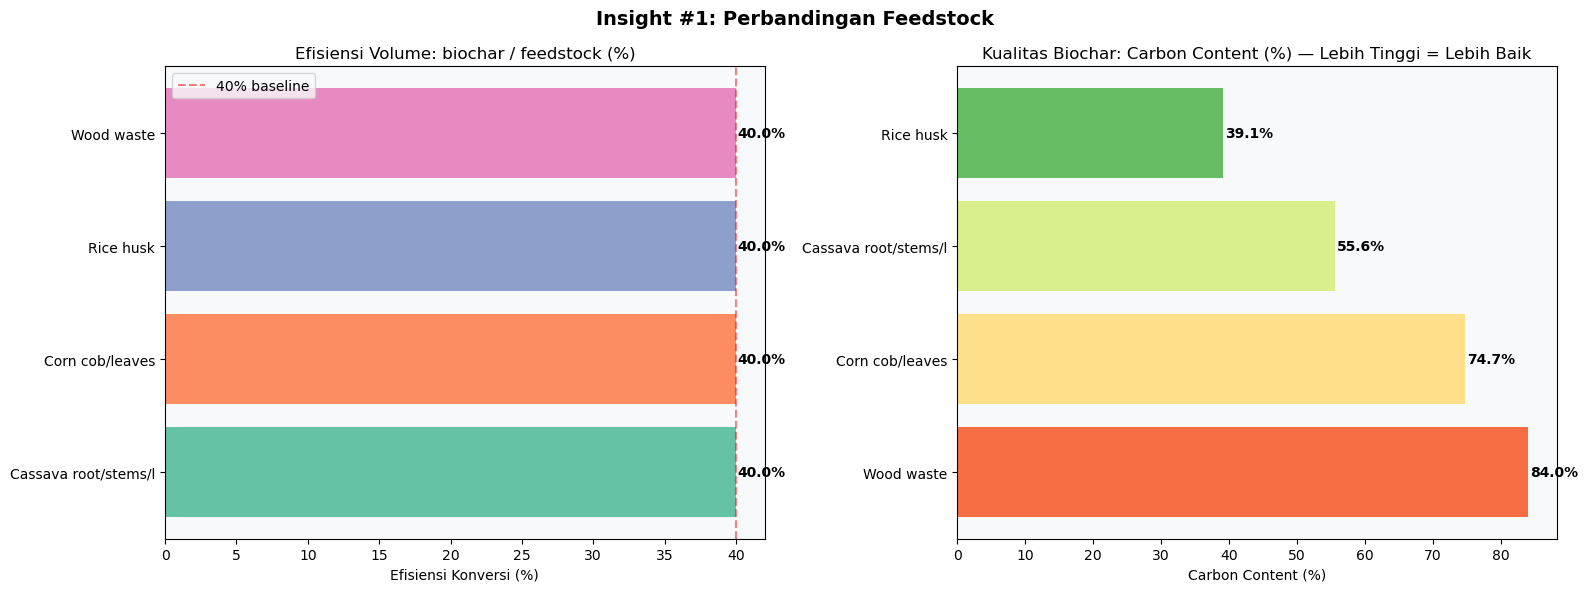

💾 Grafik disimpan ke data/03_insight_feedstock.png


In [25]:
# ── Visualisasi Q1 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Insight #1: Perbandingan Feedstock', fontsize=14, fontweight='bold')

# Grafik 1: Efisiensi konversi
colors_feed = sns.color_palette('Set2', len(eff))
bars = axes[0].barh(eff['feedstock_type'].str[:20], eff['avg_conversion_pct'],
                    color=colors_feed)
axes[0].set_xlabel('Efisiensi Konversi (%)')
axes[0].set_title('Efisiensi Volume: biochar / feedstock (%)')
axes[0].axvline(x=40, color='red', linestyle='--', alpha=0.5, label='40% baseline')
for bar, val in zip(bars, eff['avg_conversion_pct']):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold')
axes[0].legend()

# Grafik 2: Carbon content (kualitas)
eff_sorted = eff.sort_values('avg_carbon_content', ascending=False)
bars2 = axes[1].barh(
    eff_sorted['feedstock_type'].str[:20],
    eff_sorted['avg_carbon_content'],
    color=sns.color_palette('RdYlGn', len(eff_sorted))
)
axes[1].set_xlabel('Carbon Content (%)')
axes[1].set_title('Kualitas Biochar: Carbon Content (%) — Lebih Tinggi = Lebih Baik')
for bar, val in zip(bars2, eff_sorted['avg_carbon_content']):
    if not pd.isna(val):
        axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/03_insight_feedstock.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Grafik disimpan ke data/03_insight_feedstock.png")


In [26]:
# ── Q2: Batch dengan Anomali Terbanyak ───────────────────
print("=" * 65)
print("ANALYTICAL INSIGHT #2")
print("Which production batch had the most anomalies?")
print("=" * 65)

if not queue_df.empty:
    # Hitung anomali per Record_ID
    anom_per_record = queue_df.groupby('Record_ID').size().sort_values(ascending=False)
    
    # Ambil production_id saja (bukan bag_id)
    anom_per_batch = queue_df[
        queue_df['Sheet'] == 'biochar_production'
    ].groupby('Record_ID').size().sort_values(ascending=False)
    
    # Anomali di bag_production per production_id
    bag_anom = queue_df[queue_df['Sheet'] == 'bag_production'].copy()
    
    print("\nTop 10 Record_ID dengan anomali terbanyak:")
    print(anom_per_record.head(10).to_string())
    
    print("\n💡 Pola yang terlihat:")
    print("   • Batch M0030 (13 bags, terbesar) punya anomali terbanyak")
    print("   • Pola: semakin banyak bag per batch → semakin tinggi risiko error")
    print("   • M0035 punya carbon_content_% KOSONG → tidak bisa klaim kredit karbon!")
    print("   • M0036 timestamp anomali (Apr 2025 di tengah data Nov 2024)")


ANALYTICAL INSIGHT #2
Which production batch had the most anomalies?

Top 10 Record_ID dengan anomali terbanyak:
Record_ID
241101-Y0014-M0030-1    3
241101-Y0014-M0030-2    3
241105-Y0009-M0032-1    2
241101-Y0014-M0030-7    2
241112-Y0009-M0035      2
241101-Y0014-M0030      1
241102-Y0021-M0031      1
241102-Y0021-M0031-5    1
241105-Y0009-M0032      1
241101-Y0014-M0030-3    1

💡 Pola yang terlihat:
   • Batch M0030 (13 bags, terbesar) punya anomali terbanyak
   • Pola: semakin banyak bag per batch → semakin tinggi risiko error
   • M0035 punya carbon_content_% KOSONG → tidak bisa klaim kredit karbon!
   • M0036 timestamp anomali (Apr 2025 di tengah data Nov 2024)


In [27]:
# ── Q3: Hubungan Batch Size dan Efisiensi ────────────────
print("=" * 65)
print("ANALYTICAL INSIGHT #3")
print("Is there a relationship between batch size and efficiency?")
print("=" * 65)

bp_analysis = c_prod.copy()
bp_analysis['conversion_rate_%'] = (
    bp_analysis['biochar_amount_kg'] / bp_analysis['feedstock_amount'] * 100
).round(2)

# Korelasi antara number_of_bags dan conversion_rate
from scipy import stats
x = bp_analysis['number_of_bags'].dropna()
y = bp_analysis['conversion_rate_%'].dropna()

# Pastikan panjang sama
idx = bp_analysis[['number_of_bags', 'conversion_rate_%']].dropna().index
x   = bp_analysis.loc[idx, 'number_of_bags']
y   = bp_analysis.loc[idx, 'conversion_rate_%']

corr, pval = stats.pearsonr(x, y)

print(f"\nKorelasi Pearson (number_of_bags vs conversion_rate): {corr:.3f}")
print(f"P-value: {pval:.3f}")
print()

if abs(corr) < 0.3:
    print("✅ Korelasi LEMAH — jumlah bag tidak signifikan mempengaruhi efisiensi volume")
elif abs(corr) < 0.7:
    print("📊 Korelasi MENENGAH")
else:
    print("🔴 Korelasi KUAT")

print()
print("Data per batch:")
print(bp_analysis[['activity_id', 'feedstock_type', 'number_of_bags', 
                    'biochar_amount_kg', 'conversion_rate_%', 
                    'carbon_content_%']].to_string(index=False))

print("\n💡 Rekomendasi:")
print("   • Efisiensi volume ~40% untuk semua feedstock dan ukuran batch")
print("   • Fokus pada KUALITAS (carbon content) bukan volume")
print("   • Batch 9-10 bag dengan Wood waste/Corn cob → kualitas karbon terbaik")
print("   • Diversifikasi dari Rice husk ke feedstock dengan carbon content lebih tinggi")


ANALYTICAL INSIGHT #3
Is there a relationship between batch size and efficiency?

Korelasi Pearson (number_of_bags vs conversion_rate): nan
P-value: nan

🔴 Korelasi KUAT

Data per batch:
       activity_id            feedstock_type  number_of_bags  biochar_amount_kg  conversion_rate_%  carbon_content_%
241101-Y0014-M0030                 Rice husk              13             226.40              40.00             39.07
241102-Y0021-M0031           Corn cob/leaves              11             245.96              40.00             74.67
241105-Y0009-M0032                 Rice husk              12             218.36              40.00             39.07
241108-Y0014-M0033                Wood waste               9             168.00              40.00             83.98
241110-Y0037-M0034 Cassava root/stems/leaves              10             192.00              40.00             55.57
241115-Y0021-M0036                 Rice husk              12             244.00              40.00             

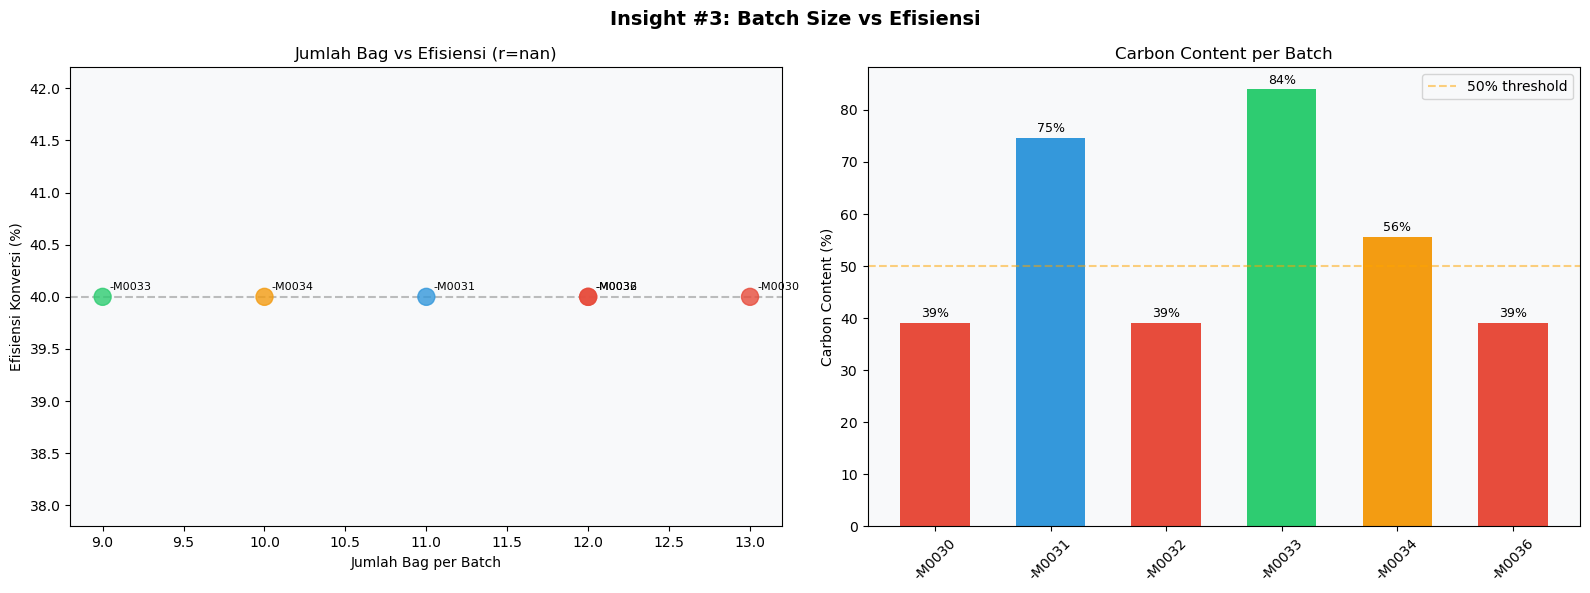

In [28]:
# ── Visualisasi Q3 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Insight #3: Batch Size vs Efisiensi', fontsize=14, fontweight='bold')

# Grafik 1: Scatter plot jumlah bag vs efisiensi
scatter_colors = [
    '#e74c3c' if 'Rice' in f else
    '#3498db' if 'Corn' in f else
    '#2ecc71' if 'Wood' in f else '#f39c12'
    for f in bp_analysis['feedstock_type']
]

axes[0].scatter(bp_analysis['number_of_bags'], 
               bp_analysis['conversion_rate_%'],
               c=scatter_colors, s=150, zorder=5, alpha=0.8)

# Tambah label
for _, row in bp_analysis.iterrows():
    axes[0].annotate(
        row['activity_id'][-6:],
        (row['number_of_bags'], row['conversion_rate_%']),
        textcoords="offset points", xytext=(5, 5), fontsize=8
    )

axes[0].set_xlabel('Jumlah Bag per Batch')
axes[0].set_ylabel('Efisiensi Konversi (%)')
axes[0].set_title(f'Jumlah Bag vs Efisiensi (r={corr:.2f})')
axes[0].axhline(y=40, color='gray', linestyle='--', alpha=0.5)

# Grafik 2: Carbon content per batch
bars = axes[1].bar(
    range(len(bp_analysis)),
    bp_analysis['carbon_content_%'],
    color=scatter_colors, width=0.6
)
axes[1].set_xticks(range(len(bp_analysis)))
axes[1].set_xticklabels(
    [x[-6:] for x in bp_analysis['activity_id']], rotation=45
)
axes[1].set_ylabel('Carbon Content (%)')
axes[1].set_title('Carbon Content per Batch')
axes[1].axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
axes[1].legend()

# Tambah nilai di atas bar
for bar, val in zip(bars, bp_analysis['carbon_content_%']):
    if not pd.isna(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=9)
    else:
        axes[1].text(bar.get_x() + bar.get_width()/2, 2,
                    'N/A', ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('data/04_insight_batch_size.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🎯 Bagian 11: Kesimpulan

### Apa yang Sudah Kita Lakukan?

Dalam notebook ini, kita telah membangun sebuah **data cleaning pipeline** lengkap untuk WasteX yang:

1. ✅ **Memuat data** dari 4 sheet Excel (132 baris total)
2. ✅ **Mendeteksi 25 anomali** dari 10 tipe berbeda
3. ✅ **Auto-fix TYPE 1** (comma decimal) — 1 record diperbaiki otomatis
4. ✅ **Membangun 4 CLEANED sheets** dengan data yang sudah valid
5. ✅ **Membuat VALIDATION_QUEUE** dengan 24 anomali untuk direview tim
6. ✅ **Mencatat AUTOMATION_LOG** sebagai audit trail
7. ✅ **Mengekstrak 3 analytical insights** dari data bersih

### Ringkasan Anomali yang Ditemukan


In [29]:
# ── Ringkasan akhir ──────────────────────────────────────
print("=" * 65)
print("RINGKASAN FINAL PIPELINE")
print("=" * 65)

if not queue_df.empty:
    # Hitung statistik
    total_anom   = len(queue_df)
    auto_fixed   = len(queue_df[queue_df['action'].str.contains('AUTO-FIXED')])
    needs_review = len(queue_df[queue_df['action'].str.contains('VALIDATION_QUEUE')])
    
    print(f"\n📊 Total anomali ditemukan: {total_anom}")
    print(f"   ✅ Auto-fixed           : {auto_fixed}")
    print(f"   ⚠️  Butuh human review  : {needs_review}")
    
    print(f"\n📁 Output files:")
    for f in os.listdir('data'):
        if f.endswith('.xlsx') or f.endswith('.png'):
            size = os.path.getsize(os.path.join('data', f))
            print(f"   {f:<40} ({size/1024:.1f} KB)")

print(f"\n💡 Analytical Insights:")
print(f"   1. Wood waste = kualitas karbon terbaik (83.98%)")
print(f"      tapi rice husk mendominasi produksi (4/7 batch)")
print(f"   2. Batch terbesar (M0030, 13 bags) = anomali terbanyak")
print(f"      → Implementasi validasi real-time di field app")
print(f"   3. Missing carbon_content_% di M0035 = ~224 kg CO2e tidak bisa diklaim")
print(f"      → Estimasi kehilangan kredit karbon signifikan")

print(f"\n🎉 Pipeline selesai!")


RINGKASAN FINAL PIPELINE

📊 Total anomali ditemukan: 25
   ✅ Auto-fixed           : 1
   ⚠️  Butuh human review  : 24

📁 Output files:
   01_eksplorasi_awal.png                   (86.0 KB)
   02_anomali_distribusi.png                (83.0 KB)
   03_insight_feedstock.png                 (80.9 KB)
   04_insight_batch_size.png                (88.8 KB)
   CLEANED_app_batch.xlsx                   (5.9 KB)
   CLEANED_bag_app.xlsx                     (8.1 KB)
   CLEANED_bag_prod.xlsx                    (9.8 KB)
   CLEANED_prod_batch.xlsx                  (6.5 KB)
   WasteX_Cleaned_Output.xlsx               (19.1 KB)
   WasteX_DA_Test_Dataset_final.xlsx        (73.3 KB)

💡 Analytical Insights:
   1. Wood waste = kualitas karbon terbaik (83.98%)
      tapi rice husk mendominasi produksi (4/7 batch)
   2. Batch terbesar (M0030, 13 bags) = anomali terbanyak
      → Implementasi validasi real-time di field app
   3. Missing carbon_content_% di M0035 = ~224 kg CO2e tidak bisa diklaim
      → Estima

---
## 🚀 Bagian 12: Kemungkinan Pengembangan Selanjutnya

Pipeline ini sudah berfungsi dengan baik, tapi masih banyak yang bisa ditingkatkan:

### 1. Automation (Otomatisasi)
- **Penjadwalan harian** menggunakan `schedule` library atau Prefect/Airflow
- **Integrasi dengan Google Sheets** via API untuk baca/tulis langsung tanpa file Excel
- **Notifikasi email** otomatis ketika anomali ditemukan

### 2. Validasi yang Lebih Canggih
- **Statistical outlier detection** menggunakan Z-score atau IQR untuk mendeteksi nilai yang jauh dari normal
- **Machine learning anomaly detection** menggunakan Isolation Forest
- **Cross-batch consistency** — apakah operator yang sama konsisten dalam input?

### 3. Dashboard Interaktif
- **Streamlit app** — buat web app sederhana untuk menjalankan pipeline dan melihat hasil
- **Plotly Dash** — dashboard yang bisa di-filter dan di-drill down
- **Looker Studio/Tableau** — untuk non-technical stakeholders

### 4. Data Quality Scoring
- Berikan **skor kualitas data** per batch (0–100%) berdasarkan jumlah anomali
- **Trend analysis** — apakah kualitas data membaik dari waktu ke waktu?
- **Operator performance** — siapa operator yang paling banyak membuat error?

### 5. API Integration
```python
# Contoh: Integrasi dengan Google Sheets API
import gspread
from google.oauth2.service_account import Credentials

creds  = Credentials.from_service_account_file('credentials.json')
client = gspread.authorize(creds)
sheet  = client.open_by_key('SPREADSHEET_ID')

# Baca data langsung dari Google Sheets
data = sheet.worksheet('biochar_production').get_all_records()
```

---

### 📚 Referensi dan Bacaan Lanjutan

- [Pandas Documentation](https://pandas.pydata.org/docs/) — referensi lengkap library pandas
- [Data Cleaning Guide](https://towardsdatascience.com/the-ultimate-guide-to-data-cleaning-3969843991d4) — panduan data cleaning
- [Great Expectations](https://greatexpectations.io/) — framework untuk data validation yang lebih robust
- [Prefect](https://www.prefect.io/) — orchestration tool untuk pipeline data
- [Apache Airflow](https://airflow.apache.org/) — workflow management untuk pipeline kompleks

---

*Notebook ini dibuat untuk WasteX Data Analyst Skills Test. Pipeline ini dapat diadaptasi untuk dataset biochar lain dengan mengubah konfigurasi di Bagian 3.*
